In [ ]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

Calculate persistent entropy transform of a signal/function

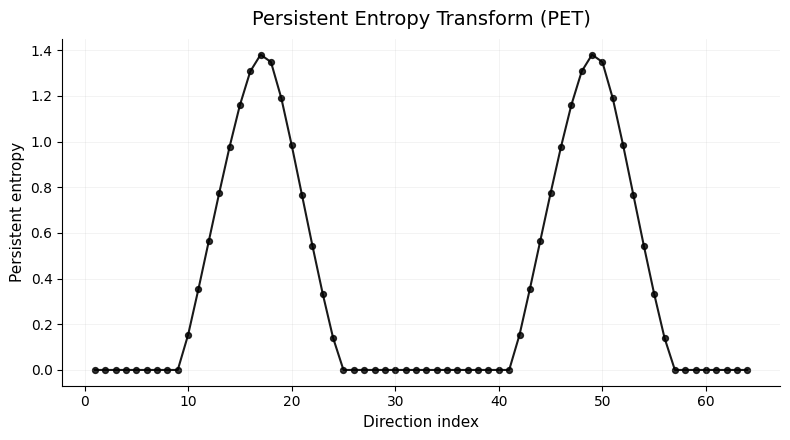

In [10]:
domain =[-10,10]
function=np.sin
n_points = 250
x_train, y_train = generate_training_data(function, (domain[0], domain[1]), n_points)
x_train = tf.constant(x_train,dtype=tf.float32)
y_train = tf.constant(y_train,dtype=tf.float32)

stbase = gd.SimplexTree()
for i in range(n_points-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgmsRef = layer.call(y_train)
dgmRef = dgmsRef[0][0]
PERef=persistent_entropy(dgmRef)


# =========================================================
# Compute PET
# =========================================================

PET_values, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

PET_values = PET_values.numpy()

# =========================================================
# Create figure
# =========================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

direction_index = np.arange(1, len(PET_values) + 1)

# Main PET curve
ax.plot(
    direction_index,
    PET_values,
    linewidth=1.5,
    color='black',
    alpha=0.9
)

# Scatter points
ax.scatter(
    direction_index,
    PET_values,
    s=18,
    color='black',
    alpha=0.8
)

# =========================================================
# Labels
# =========================================================

ax.set_xlabel(
    "Direction index",
    fontsize=11
)

ax.set_ylabel(
    "Persistent entropy",
    fontsize=11
)

ax.set_title(
    "Persistent Entropy Transform (PET)",
    fontsize=14,
    pad=10
)

# =========================================================
# Paper style
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    alpha=0.2,
    linewidth=0.5
)

plt.tight_layout()
plt.savefig("figures/Pet.jpg")
plt.show()

Display the signal from each direction

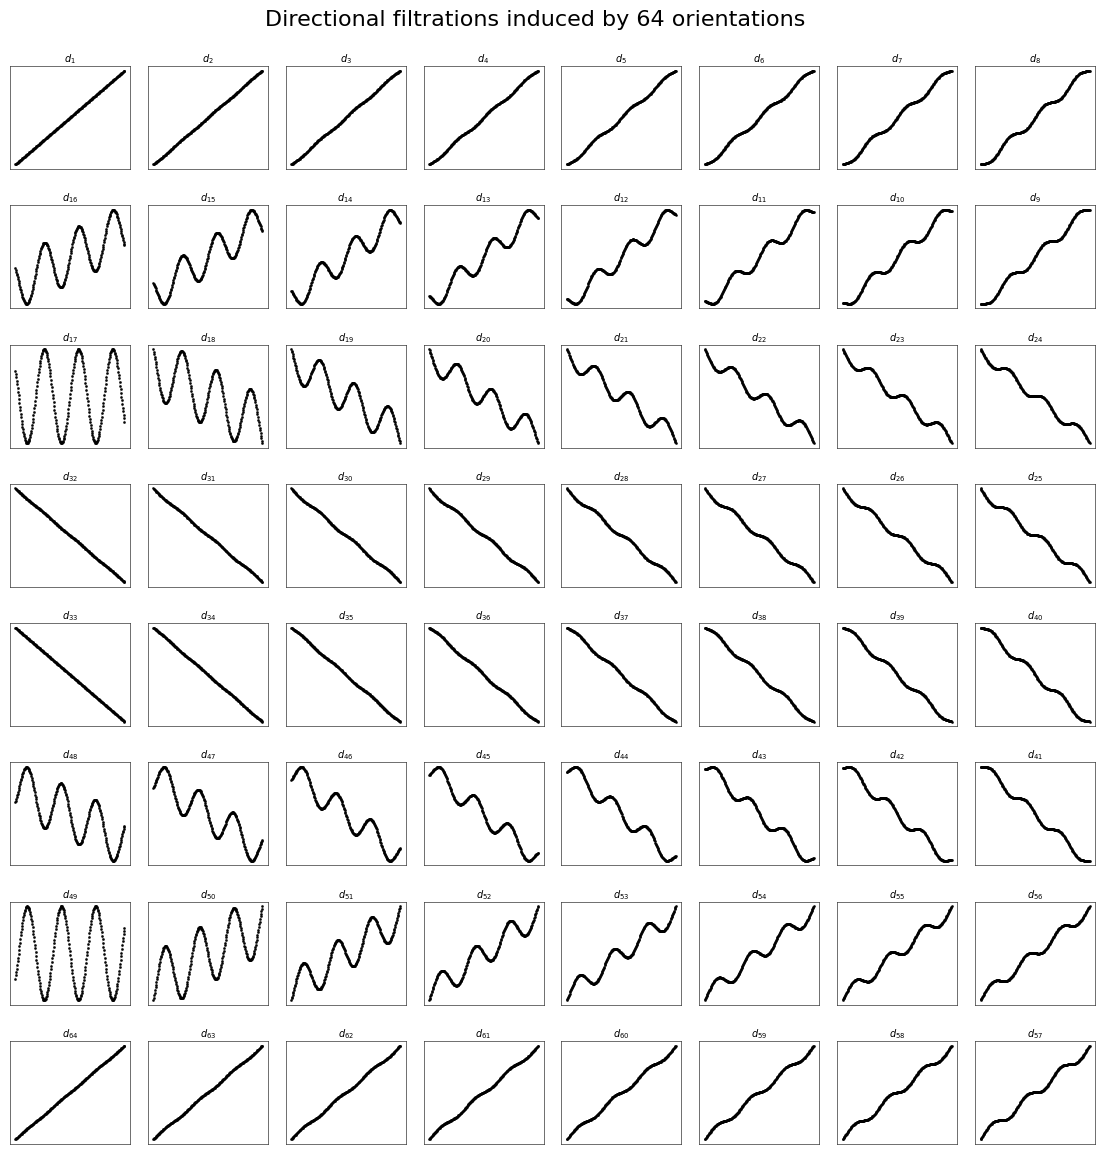

In [17]:
# display the signal from each direction

# =========================================================
# Generate directions
# =========================================================

num_directions = 64
directions, angles = generate_directions_2D(num_directions)

# =========================================================
# Reorder directions in snake-like layout
# Left -> Right
# Right -> Left
# =========================================================

grid_size = 8

ordered_indices = []

for row in range(grid_size):

    start = row * grid_size
    end = (row + 1) * grid_size

    row_indices = list(range(start, end))

    # Reverse every second row
    if row % 2 == 1:
        row_indices = row_indices[::-1]

    ordered_indices.extend(row_indices)

# =========================================================
# Create figure
# =========================================================

fig = plt.figure(figsize=(14, 14))

gs = gridspec.GridSpec(
    grid_size,
    grid_size,
    wspace=0.15,
    hspace=0.35
)

# =========================================================
# Plot directional filtrations
# =========================================================

for plot_position, k in enumerate(ordered_indices):

    direction = directions[k]

    filtration_values = directional_height_function(
        x_train,
        y_train,
        direction
    )

    ax = plt.subplot(gs[plot_position])

    x_axis = np.arange(len(filtration_values))

    ax.plot(
        x_axis,
        filtration_values,
        linewidth=0.1,
        alpha=0.85,
        color='black'
    )

    ax.scatter(
        x_axis,
        filtration_values,
        s=1,
        alpha=0.85,
        color='black'
    )

    # Minimal paper style
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        rf"$d_{{{k+1}}}$",
        fontsize=7,
        pad=2
    )

    # Thin borders
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

# =========================================================
# Global title
# =========================================================

plt.suptitle(
    "Directional filtrations induced by 64 orientations",
    fontsize=16,
    y=0.92
)

plt.savefig("figures/DirectionalFiltrations.jpg")
plt.show()


#empiezas viendolo de izquierda a derecha en el eje horizontal, asi hasta la 32 direccion, y luego de derecha a izquierda en el eje horizontal, asi hasta la 64 direccion.

empiezas viendolo de izquierda a derecha en direccion 1, ahi hasta la direccion 17 (1,57 radianes), que es de abajo a arriba, de ahi hasta la direccion 33 (3,14 radianes) que es de derecha a izquierda, y ahora por arriba igual hasta llegar a direccion 64 que es volver  casi a punto de partida


Propiedades:



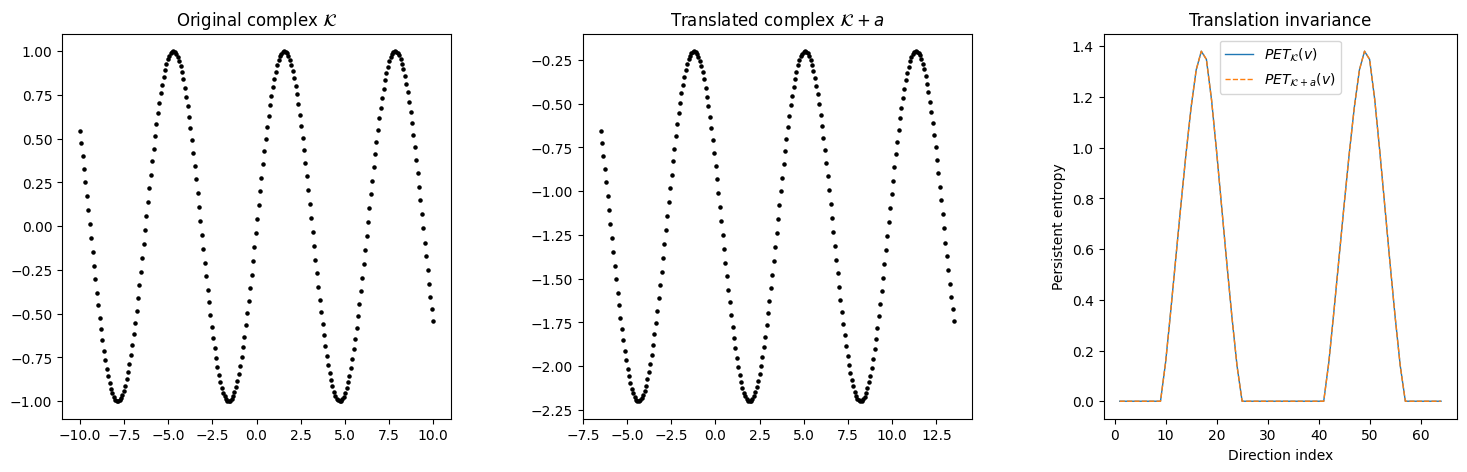

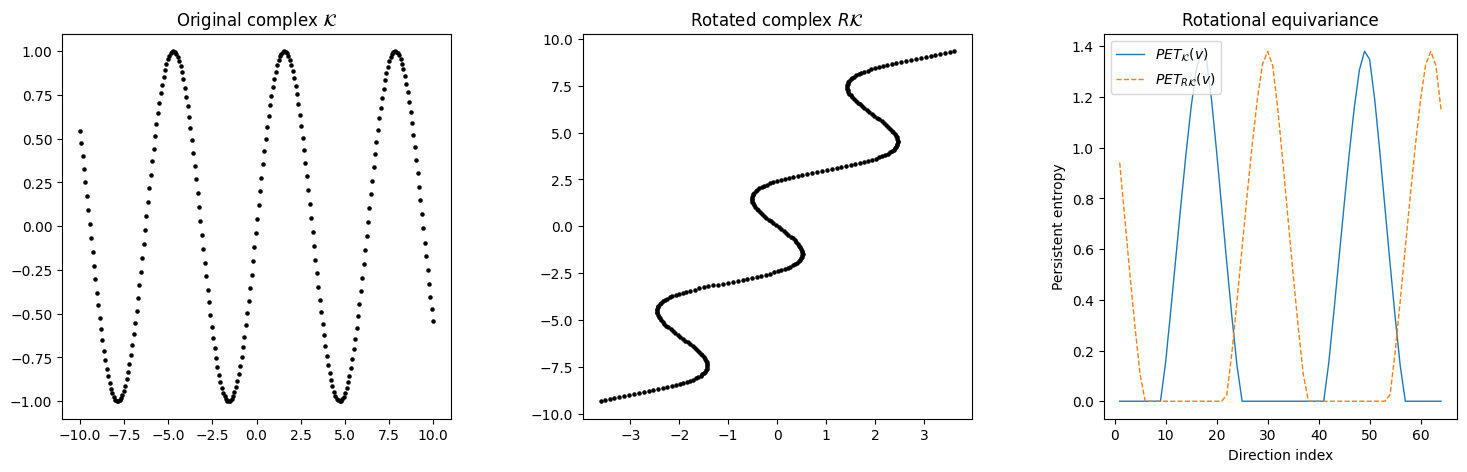

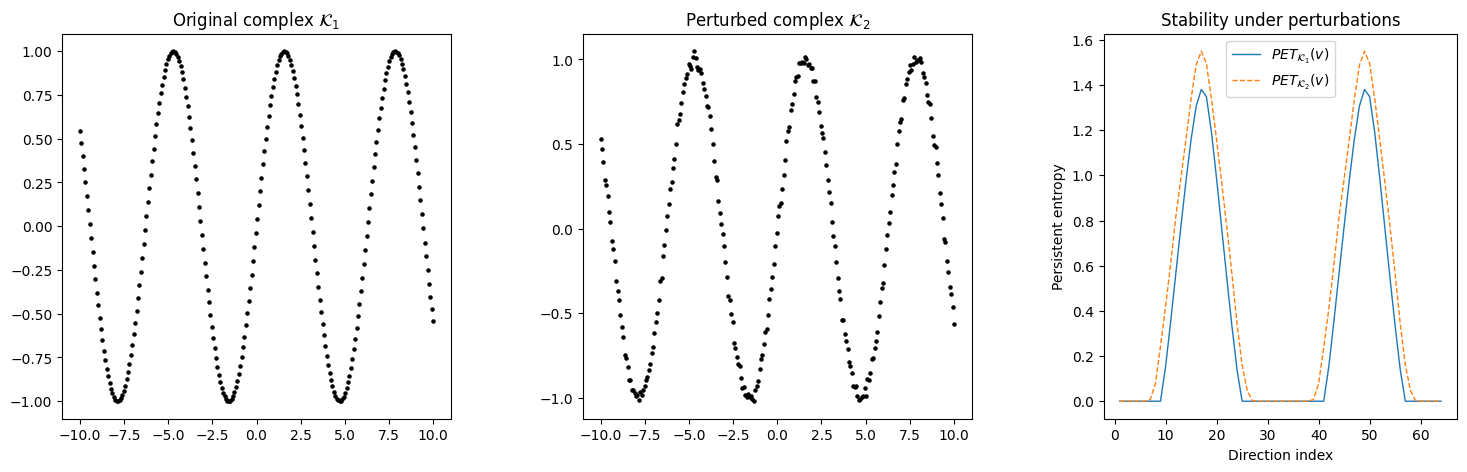

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch

# =========================================================
# DATA
# =========================================================

domain = [-10, 10]
function = np.sin
n_points = 250

x_train, y_train = generate_training_data(
    function,
    (domain[0], domain[1]),
    n_points
)

x_train = tf.constant(x_train, dtype=tf.float32)
y_train = tf.constant(y_train, dtype=tf.float32)

# =========================================================
# SIMPLEX TREE
# =========================================================

stbase = gd.SimplexTree()

for i in range(n_points - 1):
    stbase.insert([i, i + 1], -1e10)

layer = LowerStarLayer(simplextree=stbase)

# =========================================================
# PET ORIGINAL
# =========================================================

PET_original, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

PET_original = PET_original.numpy()

# =========================================================
# TRANSLATION
# =========================================================

translation = np.array([3.5, -1.2])

x_translation = x_train.numpy() + translation[0]
y_translation = y_train.numpy() + translation[1]

x_translation_tf = tf.constant(x_translation, dtype=tf.float32)
y_translation_tf = tf.constant(y_translation, dtype=tf.float32)

PET_translation, _ = persistent_entropy_transform(
    x_translation_tf,
    y_translation_tf,
    layer,
    num_directions=64
)

PET_translation = PET_translation.numpy()

# =========================================================
# ROTATION
# =========================================================

theta = np.pi / 4

rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

points = np.stack([
    x_train.numpy(),
    y_train.numpy()
], axis=1)

rotated_points = points @ rotation_matrix.T

x_rot = rotated_points[:, 0]
y_rot = rotated_points[:, 1]

x_rot_tf = tf.constant(x_rot, dtype=tf.float32)
y_rot_tf = tf.constant(y_rot, dtype=tf.float32)

PET_rotation, _ = persistent_entropy_transform(
    x_rot_tf,
    y_rot_tf,
    layer,
    num_directions=64
)

PET_rotation = PET_rotation.numpy()

# =========================================================
# PERTURBATION / STABILITY
# =========================================================

noise_level = 0.02

y_perturbed = y_train.numpy() + np.random.normal(
    0,
    noise_level,
    size=len(y_train)
)

x_perturbed_tf = tf.constant(
    x_train.numpy(),
    dtype=tf.float32
)

y_perturbed_tf = tf.constant(
    y_perturbed,
    dtype=tf.float32
)

PET_perturbed, _ = persistent_entropy_transform(
    x_perturbed_tf,
    y_perturbed_tf,
    layer,
    num_directions=64
)

PET_perturbed = PET_perturbed.numpy()

# =========================================================
# GLOBAL STYLE
# =========================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10
})

# =========================================================
# FIGURE
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)


# =========================================================
# B. TRANSLATION INVARIANCE
# =========================================================

axB1 = fig.add_subplot(gs[0, 0])

axB1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axB1.set_title(r"Original complex $\mathcal{K}$")

# ---------------------------------------------------------

axB2 = fig.add_subplot(gs[0, 1])

axB2.scatter(
    x_translation,
    y_translation,
    color='black',
    s=5
)

axB2.set_title(r"Translated complex $\mathcal{K}+a$")

# ---------------------------------------------------------

axB3 = fig.add_subplot(gs[0, 2])

axB3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}}(v)$"
)

axB3.plot(
    direction_index,
    PET_translation,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{\mathcal{K}+a}(v)$"
)

axB3.legend()
axB3.set_title("Translation invariance")
axB3.set_xlabel("Direction index")
axB3.set_ylabel("Persistent entropy")

plt.savefig("figures/TranslationInv.jpg")
plt.show()
# =========================================================
# C. ROTATIONAL EQUIVARIANCE
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)

axC1 = fig.add_subplot(gs[0, 0])

axC1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axC1.set_title(r"Original complex $\mathcal{K}$")

# ---------------------------------------------------------

axC2 = fig.add_subplot(gs[0, 1])

axC2.scatter(
    x_rot,
    y_rot,
    color='black',
    s=5
)

axC2.set_title(r"Rotated complex $R\mathcal{K}$")

# ---------------------------------------------------------

axC3 = fig.add_subplot(gs[0, 2])

axC3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}}(v)$"
)

axC3.plot(
    direction_index,
    PET_rotation,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{R\mathcal{K}}(v)$"
)

axC3.legend()
axC3.set_title("Rotational equivariance")
axC3.set_xlabel("Direction index")
axC3.set_ylabel("Persistent entropy")

plt.savefig("figures/Rotational.jpg")
plt.show()
# =========================================================
# D. STABILITY
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)

axD1 = fig.add_subplot(gs[0, 0])

axD1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axD1.set_title(r"Original complex $\mathcal{K}_1$")

# ---------------------------------------------------------

axD2 = fig.add_subplot(gs[0, 1])

axD2.scatter(
    x_train,
    y_perturbed,
    color='black',
    s=5
)

axD2.set_title(r"Perturbed complex $\mathcal{K}_2$")

# ---------------------------------------------------------

axD3 = fig.add_subplot(gs[0, 2])

axD3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}_1}(v)$"
)

axD3.plot(
    direction_index,
    PET_perturbed,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{\mathcal{K}_2}(v)$"
)

axD3.legend()

axD3.set_title("Stability under perturbations")
axD3.set_xlabel("Direction index")
axD3.set_ylabel("Persistent entropy")

plt.savefig("figures/Stability.jpg")
plt.show()



Some experiments: 1) Sensibilidad direccional

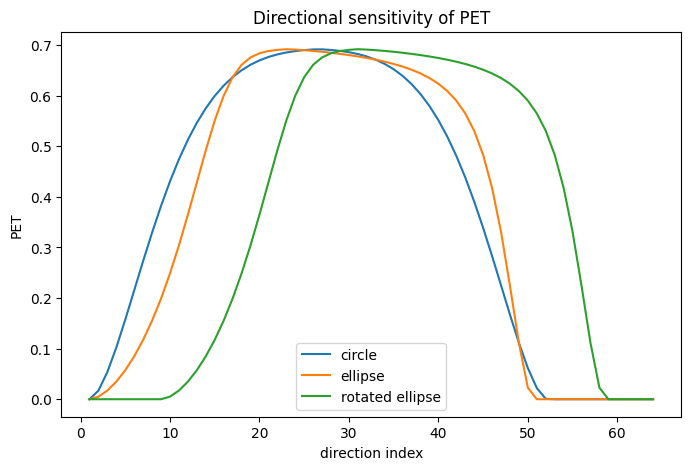

In [31]:

# ---------- SHAPE GENERATORS ----------

def generate_circle(n_points=500, radius=1.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = radius * np.cos(t)
    y = radius * np.sin(t)
    return x, y


def generate_ellipse(n_points=500, a=2.0, b=1.0, rotation=0.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = a * np.cos(t)
    y = b * np.sin(t)

    R = np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation),  np.cos(rotation)]
    ])

    pts = R @ np.vstack([x, y])
    return pts[0], pts[1]


def generate_noisy_shape(x, y, sigma):
    noise_x = np.random.normal(0, sigma, len(x))
    noise_y = np.random.normal(0, sigma, len(y))
    return x + noise_x, y + noise_y

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

def experiment_directional_sensitivity(layer):

    shapes = {
        "circle": generate_circle(),
        "ellipse": generate_ellipse(a=2, b=1),
        "rotated ellipse": generate_ellipse(a=2, b=1, rotation=np.pi/4)
    }

    plt.figure(figsize=(8,5))

    for name, (x, y) in shapes.items():
        pet, angles = compute_pet_from_shape(x, y, layer)
        direction_index = np.arange(1, len(pet) + 1)
        plt.plot(direction_index, pet, label=name)

    plt.legend()
    plt.xlabel("direction index")
    plt.ylabel("PET")
    plt.title("Directional sensitivity of PET")
    plt.savefig("figures/sensitivity.jpg")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

# Run all experiments
experiment_directional_sensitivity(layer)

2) Experimento 2: Noise robustness


=== Experiment 2: Noise robustness ===
sigma=0.00 -> distance=0.0000
sigma=0.06 -> distance=29.0767
sigma=0.11 -> distance=32.1555
sigma=0.17 -> distance=32.8483
sigma=0.22 -> distance=33.4481
sigma=0.28 -> distance=33.5949
sigma=0.33 -> distance=33.6149
sigma=0.39 -> distance=33.8314
sigma=0.44 -> distance=34.0624
sigma=0.50 -> distance=34.0568


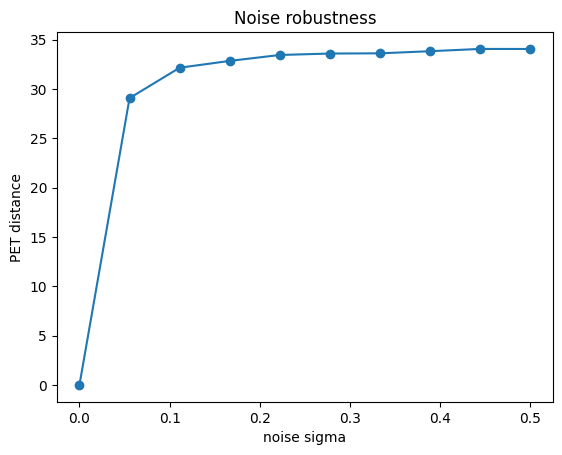

In [28]:
def experiment_noise_stability(layer):

    print("\n=== Experiment 2: Noise robustness ===")

    x,y = generate_ellipse(a=2,b=1)
    pet_clean,_ = compute_pet_from_shape(x,y,layer)

    sigmas = np.linspace(0,0.5,10)
    distances = []

    for sigma in sigmas:
        xn,yn = generate_noisy_shape(x,y,sigma)
        pet_noisy,_ = compute_pet_from_shape(xn,yn,layer)

        dist = np.linalg.norm(pet_clean - pet_noisy)
        distances.append(dist)

        print(f"sigma={sigma:.2f} -> distance={dist:.4f}")

    plt.figure()
    plt.plot(sigmas, distances, marker="o")
    plt.xlabel("noise sigma")
    plt.ylabel("PET distance")
    plt.title("Noise robustness")
    plt.savefig("figures/noiseRobustness.jpg")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_noise_stability(layer)

Experiment 3: Clasificación

In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def build_dataset(layer, n_samples=20):

    X=[]
    y_labels=[]

    for _ in range(n_samples):
        x,y = generate_circle()
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(0)

    for _ in range(n_samples):
        x,y = generate_ellipse(a=2,b=1)
        pet,_ = compute_pet_from_shape(x,y,layer)
        X.append(pet)
        y_labels.append(1)

    return np.array(X), np.array(y_labels)


def experiment_classification(layer):

    print("\n=== Experiment 3: Classification ===")

    X,y = build_dataset(layer)

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.3,random_state=0
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train,y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test,preds)

    print("Classification accuracy:",acc)

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_classification(layer)


=== Experiment 3: Classification ===
Classification accuracy: 1.0


Experiment 4: Convergencia por direcciones

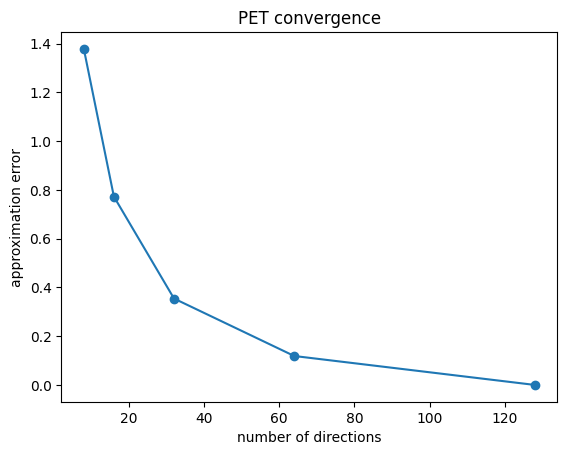

In [30]:
def experiment_direction_sampling(layer):

    x, y = generate_ellipse(a=2, b=1)

    dirs = [8,16,32,64,128]
    reference,_ = compute_pet_from_shape(x,y,layer,128)

    errors = []

    for d in dirs:
        pet,_ = compute_pet_from_shape(x,y,layer,d)
        interp = np.interp(
            np.linspace(0,1,len(reference)),
            np.linspace(0,1,len(pet)),
            pet
        )

        err = np.linalg.norm(reference - interp)
        errors.append(err)

    plt.figure()
    plt.plot(dirs, errors, marker="o")
    plt.xlabel("number of directions")
    plt.ylabel("approximation error")
    plt.title("PET convergence")
    plt.savefig("figures/convergence.jpg")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_direction_sampling(layer)

Experiment 5: Coste computacional

In [10]:
import time

def experiment_runtime(layer):

    x, y = generate_ellipse()

    for dirs in [8,16,32,64]:
        start = time.time()
        compute_pet_from_shape(x,y,layer,dirs)
        elapsed = time.time() - start

        print(f"Directions={dirs}, time={elapsed:.3f}s")

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_runtime(layer)

Directions=8, time=0.096s
Directions=16, time=0.177s
Directions=32, time=0.330s
Directions=64, time=0.601s


-- EXPERIMETNO ECG CLASIFICACION

In [35]:
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def load_twolead_ecg():
    """
    Loads TwoLeadECG dataset from UCR archive.
    Returns:
        X: signals (n_samples, time_length)
        y: labels (binary)
    """
    ucr = UCR_UEA_datasets()
    X_train, y_train, X_test, y_test = ucr.load_dataset("TwoLeadECG")

    X = np.concatenate([X_train, X_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)

    return X, y


def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """
    X_raw, y_raw = load_twolead_ecg()

    X_pet = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)


def experiment_ecg(layer, n_points=400):

    print("\n=== PET Classification on TwoLeadECG ===")

    X, y = build_dataset_from_ecg(layer, n_points=n_points)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("Accuracy:", acc)

    return acc

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_ecg(layer, n_points=n_points)


=== PET Classification on TwoLeadECG ===
Accuracy: 0.994269340974212


0.994269340974212

jupyter nbconvert --to html pet.ipynb